In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data

In [2]:
df = pd.read_csv('/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/combined_presentations_data_w3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

In [4]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


## Data preprocessing

In [5]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
# Not included: demographic features + relative_submission_date (because it would cause student who never submitted to get dropped)
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    'submission_type',
    'total_vle_pre_w3'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type
columns_to_fill_zeros = [
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3',
]
df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
df_model_clean = df_model.dropna() 


## Initial train-test split

In [6]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']


# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

In [7]:
# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {X["code_module"].value_counts(normalize = True).sort_index().values}")
print(f"Train:      {X["code_module"].loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {X["code_module"].loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57731423 0.42268577]
Train (1 = At-Risk):    [0.57720861 0.42279139]
Test (1 = At-Risk):     [0.57773655 0.42226345]

Module distribution:
------------------------------------------------------------
Original:   [0.05062727 0.39588746 0.24927622 0.08863485 0.2155742 ]
Train:      [0.05057535 0.39587973 0.24935041 0.08862287 0.21557164]
Test:       [0.05083488 0.39591837 0.24897959 0.08868275 0.21558442]


## Define models

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from xgboost.sklearn import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [9]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
              'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
              'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(drop='first'), cat_cols)],
    remainder = 'passthrough'
)

In [10]:
# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                     ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                     penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                     class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                               ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                   min_samples_split=50, min_samples_leaf=25,
                                                                   max_features='sqrt', max_samples=0.7,
                                                                   class_weight='balanced'))]),
    'Gradient Boosting': Pipeline([('preprocess', cat_processor),
                                   ('classify', GradientBoostingClassifier(random_state=SEED, n_estimators=100, 
                                                                          max_depth=3, learning_rate=0.1))]),
    'Extra Trees': Pipeline([('preprocess', cat_processor),
                            ('classify', ExtraTreesClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                             min_samples_split=50, min_samples_leaf=25,
                                                             max_features='sqrt', class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                         ('classify', XGBClassifier(random_state=SEED))])
}

## Train and compare models

In [11]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate

Note we have marked "Pass / Distinction" as 0 and "Fail / Withdrawn [after week 4]" as 1. With this encoding, "positive" classifications are "Fail / Withdrawn", and "negative" classifications are "Pass / Distinction" (in short: we are classifying whether a student is "at risk" or not.) Hence:
- the recall (also known as sensitivity) gives the proportion of at-risk students that the model correctly identifies;
- the specificity gives the proportion of not-at-risk students that the model correctly identifies;
- the precision gives the proportion of students flagged as at-risk by the model that actually fail / withdraw.
Maximizing recall corresponds to identifying as many at-risk students as possible; increasing precision corresponds to reducing the number of false positives. 

### Cross-validation using `StratifiedKFold`

In [12]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']

## Keep extra copy of column in X_train for further use in cross-validation splits
X["stratify"] = stratify_column

# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Set X_train, y_train up for stratified splits during cross-validation
y_train = X_train["stratify"]
X_train.drop(["stratify"], axis=1, inplace=True)

In [13]:
from sklearn.model_selection import StratifiedKFold

# Train and evaluate with cross-validation
results = []
skf = StratifiedKFold(n_splits=5)

for model in models:
    auc, recall, precision, f1, overfit_gap = [], [], [], [], []
    for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_index]
        y_tt = y_train.iloc[train_index].apply(lambda x: int(x[0]))

        X_ho = X_train.iloc[test_index]
        y_ho = y_train.iloc[test_index].apply(lambda x: int(x[0]))   
        
        this_model = clone(models[model])
        this_model.fit(X_tt, y_tt)
    
        y_test_pred = this_model.predict(X_ho)
        y_train_pred = this_model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = this_model.predict_proba(X_ho)[:, 1]
            y_train_proba = this_model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        precision += [precision_score(y_ho, y_test_pred)]
        f1 += [f1_score(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]
 
    # Metrics averaged across all folds
    results.append({
        'Model': model,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Precision': np.mean(precision),
        'Test F1': np.mean(f1),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

In [14]:
results_df

,Model,Test ROC-AUC,Test Recall,Test Precision,Test F1,Overfitting Gap
1,Logistic Regression,0.709116,0.615021,0.588527,0.601393,0.000068
4,Extra Trees,0.698130,0.626218,0.561661,0.592026,0.003061
2,Random Forest,0.708000,0.579254,0.600723,0.589312,0.017654
3,Gradient Boosting,0.705600,0.457866,0.659953,0.540447,0.023687
5,XGBoost,0.675579,0.487056,0.602240,0.538482,0.247122
0,Baseline (Stratified),0.498123,0.428878,0.420667,0.424733,0.004060


In [15]:
# Display results
print("\nMODEL PERFORMANCE (Cross-Validation)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ BEST ROC-AUC: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%}")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP ROC-AUC: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Recall: {runner_up['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {runner_up['Test Precision']:.1%}")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Cross-Validation)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7091       0.6150          0.5885   0.6014           0.0001
          Extra Trees        0.6981       0.6262          0.5617   0.5920           0.0031
        Random Forest        0.7080       0.5793          0.6007   0.5893           0.0177
    Gradient Boosting        0.7056       0.4579          0.6600   0.5404           0.0237
              XGBoost        0.6756       0.4871          0.6022   0.5385           0.2471
Baseline (Stratified)        0.4981       0.4289          0.4207   0.4247           0.0041

KEY INSIGHTS

✓ BEST ROC-AUC: Logistic Regression
  • ROC-AUC: 0.709 (+0.211 vs baseline)
  • Recall: 61.5% of at-risk students identified
  • Precision: 58.9%
  • Overfitting: 0.000 ✓ Well-controlled

✓ RUNNER-UP ROC-AUC: Extra Trees
  • ROC-

In [16]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'Extra Trees': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    }
}

models_to_tune = ['Logistic Regression', 'Random Forest', 'Extra Trees']
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    grid = GridSearchCV(clone(models[model_name]), param_grids[model_name], 
                        cv=5, scoring='recall', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train_numeric)
    print(f"Best params: {grid.best_params_}")
    print(f"Best recall: {grid.best_score_:.4f}")
    final_models[model_name] = grid.best_estimator_

tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']
tuned_et_model = final_models['Extra Trees']


Tuning Logistic Regression...
Fitting 5 folds for each of 99 candidates, totalling 495 fits


Best params: {'classify__C': 0.01, 'classify__l1_ratio': 0.1}
Best recall: 0.6264

Tuning Random Forest...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 10, 'classify__min_samples_leaf': 50, 'classify__min_samples_split': 25, 'classify__n_estimators': 400}
Best recall: 0.6012

Tuning Extra Trees...
Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best params: {'classify__max_depth': 4, 'classify__min_samples_leaf': 50, 'classify__min_samples_split': 25, 'classify__n_estimators': 100}
Best recall: 0.6383


## Threshold testing

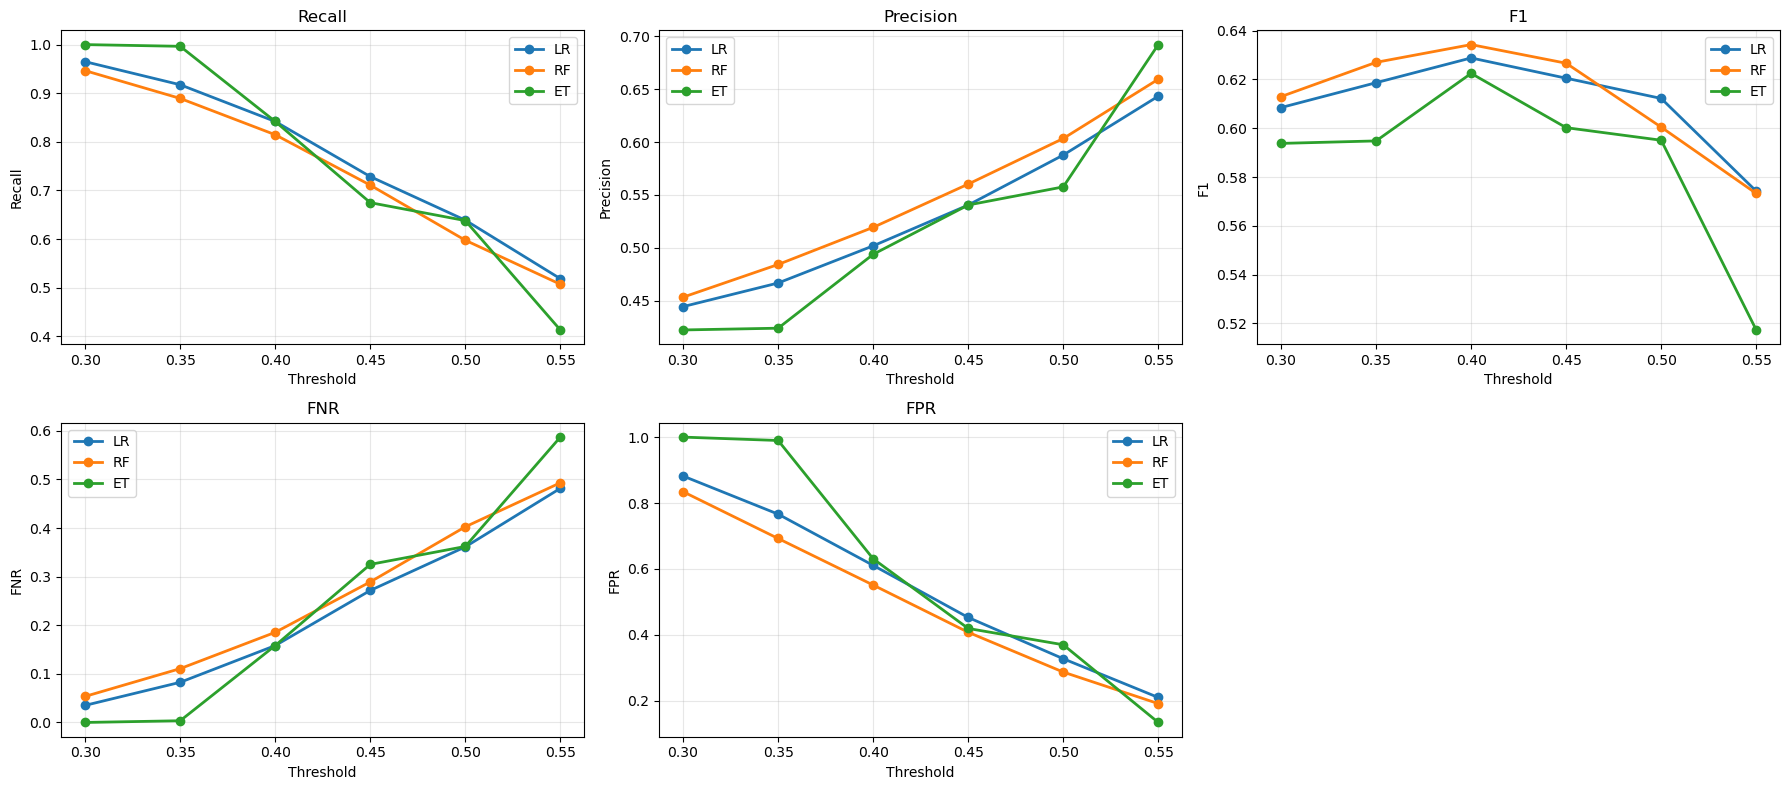

Model  Threshold   Recall  Precision       F1      FNR      FPR
   LR       0.30 0.964851   0.444355 0.608479 0.035149 0.881824
   RF       0.30 0.946397   0.453283 0.612977 0.053603 0.834297
   ET       0.30 1.000000   0.422263 0.593791 0.000000 1.000000
   LR       0.35 0.917399   0.466696 0.618667 0.082601 0.766217
   RF       0.35 0.889279   0.484211 0.627014 0.110721 0.692357
   ET       0.35 0.996485   0.423925 0.594807 0.003515 0.989724
   LR       0.40 0.841828   0.501833 0.628815 0.158172 0.610790
   RF       0.40 0.814587   0.519328 0.634280 0.185413 0.551060
   ET       0.40 0.841828   0.493814 0.622482 0.158172 0.630700
   LR       0.45 0.728471   0.540417 0.620509 0.271529 0.452794
   RF       0.45 0.710896   0.560249 0.626646 0.289104 0.407836
   ET       0.45 0.674868   0.540464 0.600234 0.325132 0.419396
   LR       0.50 0.638840   0.587712 0.612211 0.361160 0.327553
   RF       0.50 0.597540   0.603372 0.600442 0.402460 0.287091
   ET       0.50 0.637961   0.557604 0.5

In [18]:
# Threshold testing
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]
results = []

y_test_numeric = y_test if y_test.dtype != 'object' else y_test.apply(lambda x: int(x[0]))

for thresh in thresholds:
    for name, model in [('LR', tuned_lr_model), ('RF', tuned_rf_model), ('ET', tuned_et_model)]:
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= thresh).astype(int)
        
        # Calculate confusion matrix components
        tn, fp, fn, tp = confusion_matrix(y_test_numeric, y_pred).ravel()
        
        # Calculate False Negative Rate (FNR) and False Positive Rate (FPR)
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate = FN / (FN + TP)
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate = FP / (FP + TN)
        
        results.append({
            'Model': name,
            'Threshold': thresh,
            'Recall': recall_score(y_test_numeric, y_pred),
            'Precision': precision_score(y_test_numeric, y_pred),
            'F1': f1_score(y_test_numeric, y_pred),
            'FNR': fnr,
            'FPR': fpr
        })

df_results = pd.DataFrame(results)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for idx, metric in enumerate(['Recall', 'Precision', 'F1', 'FNR', 'FPR']):
    ax = axes[idx]
    for model in ['LR', 'RF', 'ET']:
        data = df_results[df_results['Model'] == model]
        ax.plot(data['Threshold'], data[metric], 'o-', label=model, linewidth=2)
    ax.set_xlabel('Threshold')
    ax.set_ylabel(metric)
    ax.set_title(metric)
    ax.legend()
    ax.grid(alpha=0.3)

# Hide the extra subplot (6th position)
axes[5].axis('off')

plt.tight_layout()
plt.show()

print(df_results.to_string(index=False))

## Feature importance analysis before running the model on the test holdout data


LR - Top 10 Features
                    Feature     Value
      submission_type_Never  1.001274
       submission_type_Late -0.639821
            code_module_FFF  0.514084
           total_vle_pre_w3 -0.256666
            code_module_BBB -0.138166
active_days_per_week_pre_w3 -0.128478
        vle_richness_pre_w3 -0.120604
            code_module_DDD  0.103285
            code_module_CCC  0.087350
 collaborative_focus_pre_w3 -0.084919

RF - Top 10 Features
                    Feature    Value
      submission_type_Never 0.207072
       submission_type_Late 0.196964
           total_vle_pre_w3 0.174111
 collaborative_focus_pre_w3 0.087331
      std_regularity_pre_w3 0.072516
active_days_per_week_pre_w3 0.059089
   diversity_shannon_pre_w3 0.054299
       content_focus_pre_w3 0.049672
        vle_richness_pre_w3 0.037175
            code_module_BBB 0.022959

ET - Top 10 Features
                    Feature    Value
      submission_type_Never 0.444102
       submission_type_Late 0.30608

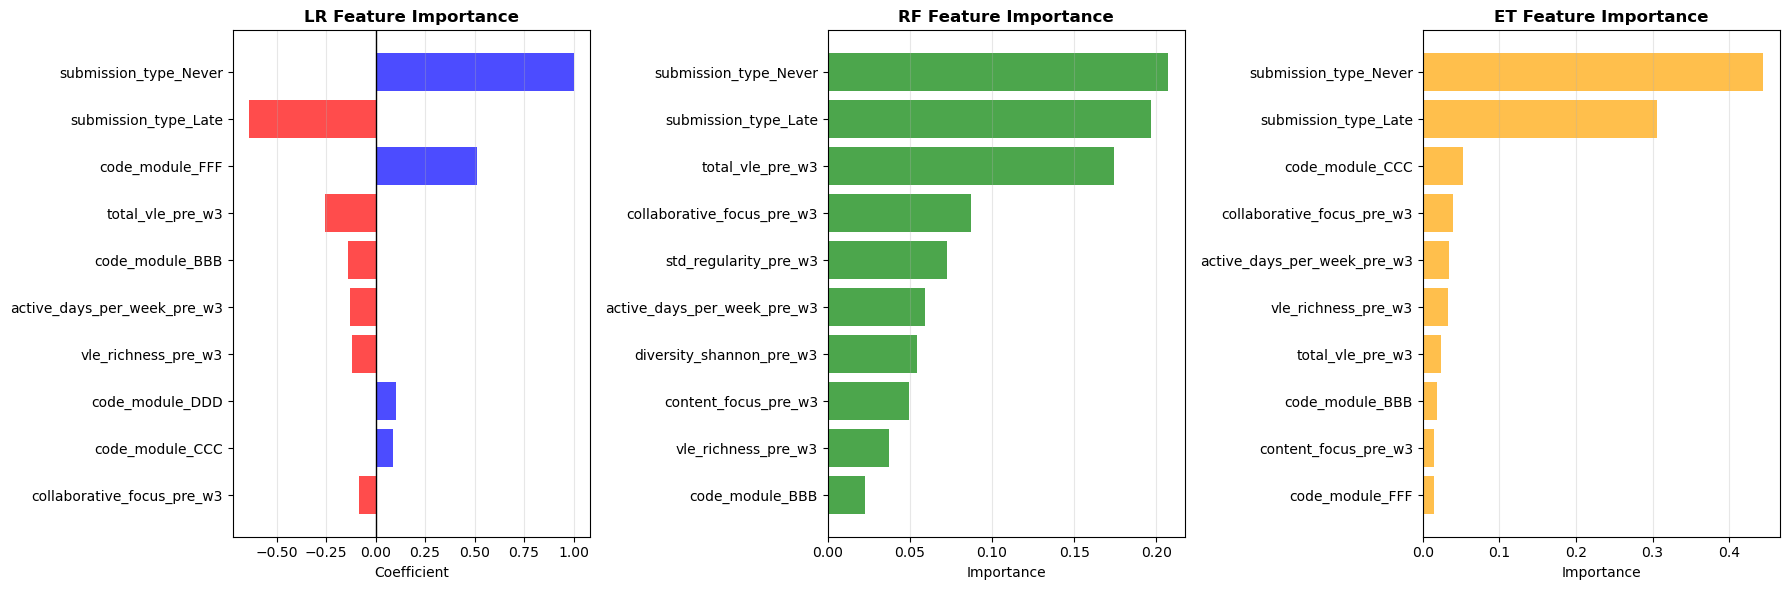

In [19]:
# Feature Importance Analysis
cat_features = list(tuned_lr_model.named_steps['preprocess'].named_transformers_['cat_encode'].get_feature_names_out(cat_cols))
all_features = scale_cols + cat_features

# Extract importances
importances = {
    'LR': pd.DataFrame({
        'Feature': all_features,
        'Value': tuned_lr_model.named_steps['classify'].coef_[0]
    }).sort_values('Value', key=abs, ascending=False),
    'RF': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_rf_model.named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False),
    'ET': pd.DataFrame({
        'Feature': cat_features + scale_cols,
        'Value': tuned_et_model.named_steps['classify'].feature_importances_
    }).sort_values('Value', ascending=False)
}

# Display top 10
for model, df in importances.items():
    print(f"\n{model} - Top 10 Features")
    print("=" * 60)
    print(df.head(10).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = {'LR': ['red' if v < 0 else 'blue' for v in importances['LR'].head(10)['Value']], 
          'RF': 'green', 'ET': 'orange'}

for ax, (model, df) in zip(axes, importances.items()):
    top = df.head(10)
    ax.barh(range(len(top)), top['Value'], color=colors[model], alpha=0.7)
    ax.set_yticks(range(len(top)))
    ax.set_yticklabels(top['Feature'])
    if model == 'LR':
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Coefficient' if model == 'LR' else 'Importance')
    ax.set_title(f'{model} Feature Importance', fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Run model on test holdout data

TEST SET PERFORMANCE (Threshold = 0.35)
Model  ROC-AUC  Recall  Precision     F1    FNR    FPR
   LR   0.7176  0.9174     0.4667 0.6187 0.0826 0.7662
   RF   0.7232  0.8893     0.4842 0.6270 0.1107 0.6924


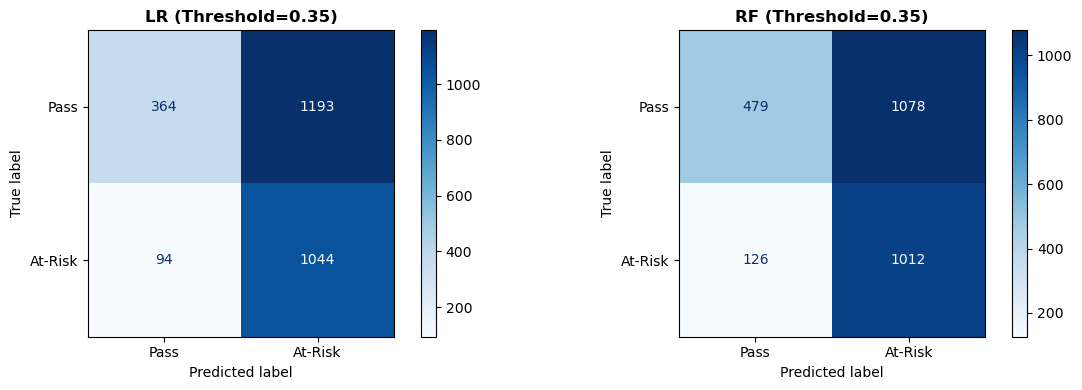

In [22]:
# Test Set Evaluation at Threshold 0.35
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_test_numeric = y_test if y_test.dtype != 'object' else y_test.apply(lambda x: int(x[0]))
models_eval = [('LR', tuned_lr_model), ('RF', tuned_rf_model)]

# Calculate metrics
results = []
for name, model in models_eval:
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.35).astype(int)
    
    # Calculate confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_test_numeric, y_pred).ravel()
    
    # Calculate FNR and FPR
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate = FN / (FN + TP)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate = FP / (FP + TN)
    
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test_numeric, y_proba),
        'Recall': recall_score(y_test_numeric, y_pred),
        'Precision': precision_score(y_test_numeric, y_pred),
        'F1': f1_score(y_test_numeric, y_pred),
        'FNR': fnr,
        'FPR': fpr
    })

print("TEST SET PERFORMANCE (Threshold = 0.35)")
print("=" * 60)
print(pd.DataFrame(results).to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for idx, (name, model) in enumerate(models_eval):
    y_pred = (model.predict_proba(X_test)[:, 1] >= 0.35).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test_numeric, y_pred), 
                          display_labels=['Pass', 'At-Risk']).plot(cmap='Blues', ax=axes[idx], values_format='d')
    axes[idx].set_title(f'{name} (Threshold=0.35)', fontweight='bold')
plt.tight_layout()
plt.show()